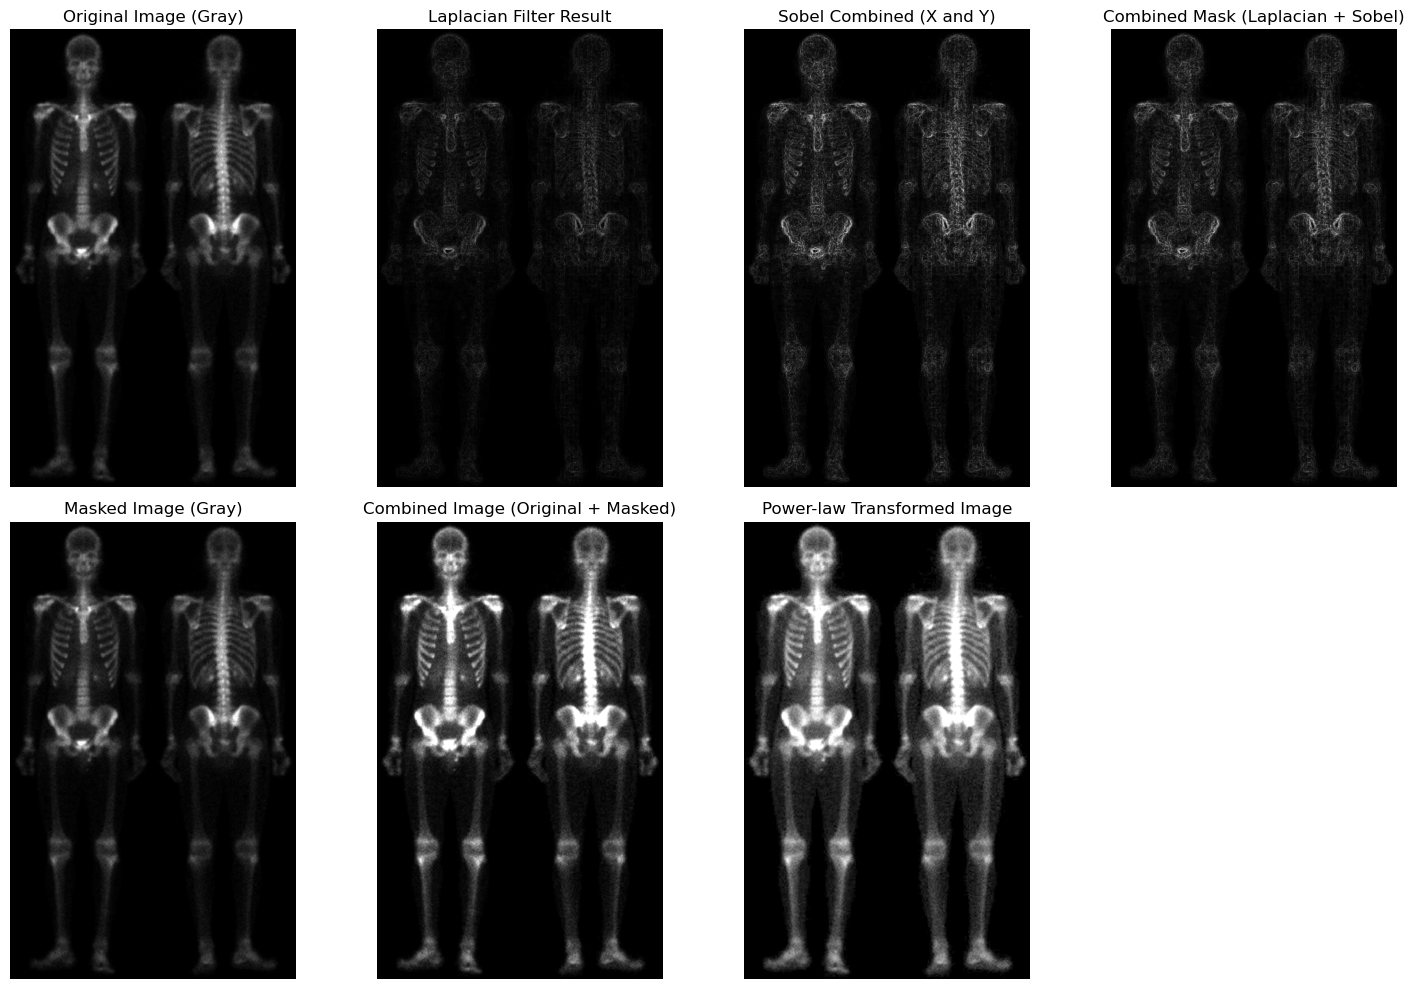

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


image = Image.open("C:\\Users\\munev\\OneDrive\\Masaüstü\\Görüntü İşleme\\Fig0206.tif")
image_np = np.array(image)


if len(image_np.shape) == 2: 
    gray_image = image_np  
else:  
    gray_image = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)

laplacian = cv2.Laplacian(gray_image, cv2.CV_64F)
laplacian = np.uint8(np.absolute(laplacian))

sharpened_image = cv2.subtract(gray_image, laplacian)

sobel_x = cv2.Sobel(sharpened_image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(sharpened_image, cv2.CV_64F, 0, 1, ksize=3)

sobel_x = np.uint8(np.absolute(sobel_x))
sobel_y = np.uint8(np.absolute(sobel_y))
sobel_combined = cv2.bitwise_or(sobel_x, sobel_y)

mask = cv2.addWeighted(laplacian, 0.5, sobel_combined, 0.5, 0)

masked_image = gray_image * (mask > 0).astype(np.uint8)

combined_image = cv2.add(gray_image, masked_image)

gamma = 0.7  

power_law_image = np.array(255 * (combined_image / 255) ** gamma, dtype=np.uint8)


plt.figure(figsize=(15, 10))

plt.subplot(2, 4, 1)
plt.imshow(gray_image, cmap='gray')
plt.title('Original Image (Gray)')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian Filter Result')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(sobel_combined, cmap='gray')
plt.title('Sobel Combined (X and Y)')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(mask, cmap='gray')
plt.title('Combined Mask (Laplacian + Sobel)')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(masked_image, cmap='gray')
plt.title('Masked Image (Gray)')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(combined_image, cmap='gray')
plt.title('Combined Image (Original + Masked)')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(power_law_image, cmap='gray')
plt.title('Power-law Transformed Image')
plt.axis('off')

plt.tight_layout()
plt.show()
